**Goal:** take the 5,574 x 2,003 feature matrix you built in L10 and find the
features that actually matter -- rank them with a chi-square filter, hand the
survivors to a decision tree you can read aloud, and check the price of
selection against an honest baseline. Pairs with the concept note
[Finding the Features That Matter: Filters, Trees, and Forests](l11_concept_feature_selection.qmd).

> This page is the read-only view. To run the lab, open the notebook
> (`l11_lab_feature_selection_spam.ipynb`) -- in Colab via the badge on the
> concept page, or locally.

## Prerequisites & Setup

Run this first. Same dataset as L10 -- the **SMS Spam Collection**: 5,574 real
text messages labeled `ham` or `spam` (Almeida, Gomez Hidalgo & Yamakami 2011;
UCI Machine Learning Repository id 228, CC BY 4.0), bundled as
`data/sms_spam.csv` with a UCI download fallback.

In [1]:
# Setup: run this cell first (required for Colab -- it resets on open)
%pip install -q pandas matplotlib scikit-learn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# SMS Spam Collection -- Almeida, Gomez Hidalgo & Yamakami (2011); UCI id 228; CC BY 4.0
LOCAL = "data/sms_spam.csv"
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

if os.path.exists(LOCAL):
    sms = pd.read_csv(LOCAL)
else:
    import io, zipfile, urllib.request
    with urllib.request.urlopen(URL) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    sms = pd.read_table(z.open("SMSSpamCollection"), header=None,
                        names=["label", "message"], quoting=3)

print(sms.shape)

Note: you may need to restart the kernel to use updated packages.


(5574, 2)


<details><summary>Expected Output</summary>

~~~text
(5574, 2)
~~~
</details>

Now rebuild L10's feature matrix -- the exact same recipe: three handcrafted
features plus a 2,000-word bag of words, stacked side by side. (`hstack` glues
sparse matrices together column-wise; the handcrafted columns ride along as
columns 2000-2002.)

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix

sms["length"] = sms["message"].str.len()
sms["digit_count"] = sms["message"].str.count(r"\d")
sms["exclam_count"] = sms["message"].str.count("!")

vectorizer = CountVectorizer(stop_words="english", max_features=2000)
X_counts = vectorizer.fit_transform(sms["message"])

handcrafted = ["length", "digit_count", "exclam_count"]
X = hstack([X_counts, csr_matrix(sms[handcrafted].values)]).tocsr()
feature_names = np.array(list(vectorizer.get_feature_names_out()) + handcrafted)

y = (sms["label"] == "spam").astype(int)

print("Feature matrix:", X.shape)
print("Last 5 feature names:", list(feature_names[-5:]))

Feature matrix: (5574, 2003)
Last 5 feature names: ['yup', 'zed', 'length', 'digit_count', 'exclam_count']


<details><summary>Expected Output</summary>

~~~text
Feature matrix: (5574, 2003)
Last 5 feature names: ['yup', 'zed', 'length', 'digit_count', 'exclam_count']
~~~
</details>

> **Read it:** 2,003 candidate features and one label column `y` (1 = spam).
> The question of the day: how few of these columns can we keep and still tell
> spam from ham?

## Step 1: An Honest Yardstick -- Baseline and Train/Test Split (Worked)

Before scoring anything, two pieces of discipline from the concept note. First,
the **baseline**: 86.6% of messages are ham, so "predict ham for everything"
is the score to beat. Second, the **train/test split**: every learned step from
here on -- selection included -- is fit on 70% of the data and graded on the
30% it never saw.

In [3]:
from sklearn.model_selection import train_test_split

print(f"Majority-class baseline: predict 'ham' for everything -> {(y == 0).mean():.1%} accuracy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training messages:", X_train.shape[0])
print("Test messages:    ", X_test.shape[0])
print(f"Spam share -- train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

Majority-class baseline: predict 'ham' for everything -> 86.6% accuracy
Training messages: 3901
Test messages:     1673
Spam share -- train: 13.4%, test: 13.4%


<details><summary>Expected Output</summary>

~~~text
Majority-class baseline: predict 'ham' for everything -> 86.6% accuracy
Training messages: 3901
Test messages:     1673
Spam share -- train: 13.4%, test: 13.4%
~~~
</details>

> **Read it:** `stratify=y` keeps the spam share identical (13.4%) on both
> sides of the split -- without it, chance could hand the test set a different
> class mix and quietly distort every accuracy we measure. From here on,
> nothing is allowed to learn from `X_test`.

## Step 2: Filter -- Rank All 2,003 Features with Chi-Square (Worked + Completion)

The chi-square score asks, for each feature independently: do its values differ
across the classes more than chance would predict? One call scores all 2,003
candidates -- on the training split only.

In [4]:
from sklearn.feature_selection import SelectKBest, chi2

scores, _ = chi2(X_train, y_train)
ranking = pd.Series(scores, index=feature_names).sort_values(ascending=False)
print(ranking.head(15).round(1))

digit_count     44045.6
length          24515.3
free              812.3
txt               631.4
exclam_count      529.6
claim             497.3
www               442.1
stop              402.7
mobile            384.7
prize             374.6
text              318.9
uk                314.7
reply             306.0
150p              284.2
cash              264.9
dtype: float64


<details><summary>Expected Output</summary>

~~~text
digit_count     44045.6
length          24515.3
free              812.3
txt               631.4
exclam_count      529.6
claim             497.3
www               442.1
stop              402.7
mobile            384.7
prize             374.6
text              318.9
uk                314.7
reply             306.0
150p              284.2
cash              264.9
dtype: float64
~~~
</details>

> **Read it:** look at the top of the leaderboard. The three features *you
> handcrafted in L10* -- `digit_count`, `length`, `exclam_count` -- all rank in
> the top 5, ahead of 1,998 of the 2,000 vocabulary columns. `digit_count`
> scores fifty times higher than `free`, the best word. The vocabulary entries
> that do rank high read like a parody of spam: free, txt, claim, www, prize.
> Domain insight beat the machinery, again.

Keep the top 30 and build the smaller matrices everything downstream will use:

In [5]:
selector = SelectKBest(chi2, k=30).fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

kept = feature_names[selector.get_support()]
print("Kept", X_train_sel.shape[1], "of", X_train.shape[1], "features:")
print(sorted(kept))

Kept 30 of 2003 features:
['100', '150p', '16', '18', '50', '500', 'awarded', 'cash', 'claim', 'com', 'cs', 'digit_count', 'exclam_count', 'free', 'guaranteed', 'length', 'mobile', 'nokia', 'prize', 'reply', 'service', 'stop', 'text', 'tone', 'txt', 'uk', 'urgent', 'win', 'won', 'www']


<details><summary>Expected Output</summary>

~~~text
Kept 30 of 2003 features:
['100', '150p', '16', '18', '50', '500', 'awarded', 'cash', 'claim', 'com', 'cs', 'digit_count', 'exclam_count', 'free', 'guaranteed', 'length', 'mobile', 'nokia', 'prize', 'reply', 'service', 'stop', 'text', 'tone', 'txt', 'uk', 'urgent', 'win', 'won', 'www']
~~~
</details>

> **Read it:** the survivors are the three handcrafted features, the spam
> vocabulary (claim, prize, urgent, win, won, guaranteed), and -- a nice touch
> -- raw number tokens like `150p` and `500`: prices and shortcodes that the
> digit counter sees only in aggregate.

Your turn -- the *other* end of the ranking is just as instructive. Which
features are most useless?

In [6]:
# Uncomment and fill the ____ : show the 10 LOWEST-scoring features
# (sort the ranking from smallest to largest, then take the first 10).
# weakest = ranking.sort_values(ascending=____).head(10)
# print(weakest.round(3))

<details><summary>Expected Output</summary>

~~~text
email       0.000
start       0.000
check       0.004
somebody    0.005
round       0.005
slow        0.005
page        0.005
fact        0.005
em          0.005
glad        0.005
dtype: float64
~~~
*(The word "email" scores 0.000 to three decimals: it appears at almost exactly
the same rate in spam and ham, so it carries essentially no information about
the label. A column can be frequent and still be worthless.)*
</details>

## Step 3: A Tree You Can Read Aloud (Worked)

Hand the 30 survivors to a decision tree with a strict honesty budget: at most
three questions per message (`max_depth=3`).

In [7]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree_sel = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_sel.fit(X_train_sel, y_train)

print(export_text(tree_sel, feature_names=list(kept)))
print(f"Test accuracy: {tree_sel.score(X_test_sel, y_test):.1%}")

|--- digit_count <= 4.50
|   |--- www <= 0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 0
|   |   |--- mobile >  0.50
|   |   |   |--- class: 1
|   |--- www >  0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 1
|   |   |--- mobile >  0.50
|   |   |   |--- class: 0
|--- digit_count >  4.50
|   |--- digit_count <= 9.50
|   |   |--- length <= 176.00
|   |   |   |--- class: 1
|   |   |--- length >  176.00
|   |   |   |--- class: 0
|   |--- digit_count >  9.50
|   |   |--- length <= 182.00
|   |   |   |--- class: 1
|   |   |--- length >  182.00
|   |   |   |--- class: 0

Test accuracy: 97.8%


<details><summary>Expected Output</summary>

~~~text
|--- digit_count <= 4.50
|   |--- www <= 0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 0
|   |   |--- mobile >  0.50
|   |   |   |--- class: 1
|   |--- www >  0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 1
|   |   |--- mobile >  0.50
|   |   |   |--- class: 0
|--- digit_count >  4.50
|   |--- digit_count <= 9.50
|   |   |--- length <= 176.00
|   |   |   |--- class: 1
|   |   |--- length >  176.00
|   |   |   |--- class: 0
|   |--- digit_count >  9.50
|   |   |--- length <= 182.00
|   |   |   |--- class: 1
|   |   |--- length >  182.00
|   |   |   |--- class: 0

Test accuracy: 97.8%
~~~
</details>

> **Read it:** read the tree like the concept note's toy (class 0 = ham,
> 1 = spam): *"Fewer than five digits? Then it's ham -- unless it mentions
> 'www' or 'mobile'. Five or more digits? Then it's spam -- unless it's
> suspiciously long."* The root split -- the single most valuable question the
> algorithm could find among all 30 features -- is `digit_count`, the column
> you invented with one line of `str.count` in L10. And this readable rule
> scores 97.8% on messages it never saw, against an 86.6% baseline.

## Step 4: The Showdown -- 30 Features vs 2,003 (Worked)

What did selection cost? Fit the identical tree on the full matrix and compare.

In [8]:
tree_all = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_all.fit(X_train, y_train)

results = [
    (f"Depth-3 tree, all {X_train.shape[1]:,} features", tree_all.score(X_test, y_test)),
    ("Depth-3 tree, top 30 features", tree_sel.score(X_test_sel, y_test)),
    ("Majority-class baseline", (y_test == 0).mean()),
]
for name, acc in results:
    print(f"{name:<36} {acc:.1%}")

Depth-3 tree, all 2,003 features     98.0%
Depth-3 tree, top 30 features        97.8%
Majority-class baseline              86.6%


<details><summary>Expected Output</summary>

~~~text
Depth-3 tree, all 2,003 features     98.0%
Depth-3 tree, top 30 features        97.8%
Majority-class baseline              86.6%
~~~
</details>

> **Read it:** dropping 1,973 features cost 0.2 percentage points. Thirty
> columns do the work of two thousand, because the signal was concentrated in
> a handful of features all along -- which is exactly what Step 2's leaderboard
> (a few huge scores, then a long tail of near-zeros) was telling us.

## Step 5: The Random Forest -- Accuracy and a Second Opinion (Worked + Completion)

A forest grows 200 randomized trees and lets them vote. Two things to collect:
its accuracy, and its feature-importance ranking -- a second, independent
opinion on which features matter.

In [9]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)

print(f"Random forest, all features: {forest.score(X_test, y_test):.1%}")

Random forest, all features: 99.1%


<details><summary>Expected Output</summary>

~~~text
Random forest, all features: 99.1%
~~~
</details>

> **Read it:** 1.3 points above the top-30 tree and 12.5 above the baseline --
> the vote of 200 trees is the most accurate model in this lab. Hold the "is
> that worth it?" question for Exercise 3.

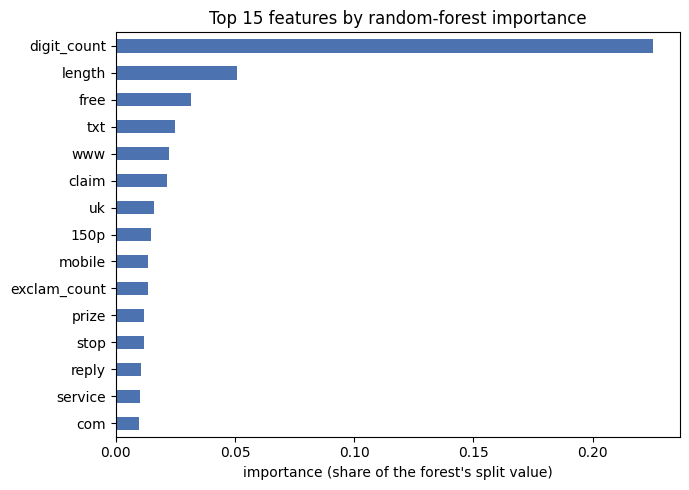

In [10]:
importances = pd.Series(forest.feature_importances_, index=feature_names)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top15.sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("importance (share of the forest's split value)")
ax.set_title("Top 15 features by random-forest importance")
plt.tight_layout()
plt.show()

> **Read it:** compare this leaderboard with Step 2's: `digit_count` and
> `length` on top, then free, txt, www, claim. The chi-square filter and the
> forest share no machinery -- one is a statistical test, the other an average
> over 200 trees -- yet they crown the same features. When two unrelated
> methods agree on what matters, that agreement is evidence.

Your turn -- the forest can also tell us how much of the matrix it *ignores*:

In [11]:
# Uncomment and fill the ____ : count the features whose importance is
# below 0.0001 (they contribute essentially nothing to the forest's votes).
# n_ignored = (importances < ____).sum()
# print(f"{n_ignored} of {len(importances)} features have importance below 0.0001")

<details><summary>Expected Output</summary>

~~~text
1280 of 2003 features have importance below 0.0001
~~~
*(Nearly two thirds of the matrix is dead weight even to the model that uses
all of it -- the forest quietly performs its own feature selection.)*
</details>

## Your Turn (Exercises)

### Exercise 1 -- Turn the knobs

How sensitive is the result to our choices? Re-run the select-then-tree
pipeline with `k=10` and `k=100` (depth 3), and with `max_depth=2` and
`max_depth=5` (k=30). Print the four test accuracies and write one sentence on
what you observe.

> **Hint:** wrap the Step 2-3 calls in a loop over k values; only the
> `SelectKBest(chi2, k=...)` and `DecisionTreeClassifier(max_depth=...)`
> arguments change. Use FRESH variable names inside your loop (e.g. `sel_k`,
> `tree_k`) -- Exercise 2 reuses Step 3's `tree_sel` and `X_test_sel`, so
> don't overwrite them.

In [12]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
k= 10, depth=3: 97.8%
k=100, depth=3: 97.8%
k= 30, depth=2: 97.5%
k= 30, depth=5: 97.7%
~~~
*(The result is a plateau: ten features or a hundred, two questions or five,
the accuracy barely moves. Once digit_count and a few spam words are in, the
remaining features add almost nothing -- the signal really is that
concentrated.)*
</details>

### Exercise 2 -- Read the mistakes

The top-30 tree gets 97.8% right. Look at what it gets *wrong*: predict on the
test set, count the misclassified messages, and print the first three with
their true labels (the first 90 characters is plenty). One sentence: what
fooled the tree?

> **Hint:** `tree_sel.predict(X_test_sel)` gives predictions;
> `y_test.index[y_test.values != y_pred]` gives the original row numbers of
> the mistakes, which `sms.loc[...]` can look up.

In [13]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
Misclassified: 37 of 1673 test messages
  true=ham: 1Apple/Day=No Doctor. 1Tulsi Leaf/Day=No Cancer. 1Lemon/Day=No Fat. 1Cup Milk/day=No Bone
  true=spam: Your weekly Cool-Mob tones are ready to download !This weeks new Tones include: 1) Crazy F
  true=ham: .Please charge my mobile when you get up in morning.
~~~
*(The tree fails exactly where its features mislead: a chain-letter ham message
stuffed with digits reads as spam; a ham message containing the word "mobile"
trips the www/mobile branch; and a spam ad happens to dodge the thresholds.
Every model's mistakes are a map of its features' blind spots.)*
</details>

### Exercise 3 -- Written: argue the case

A teammate looks at Step 5 and says: *"The forest gets 99.1%, the tree only
97.8% -- always ship the forest."* Argue for or against, in 3-4 sentences,
using at least one piece of evidence from this lab. Consider what this unit is
named after: extracting *information* from data.

> **Hint:** what can you hand to a boss, an auditor, or a curious user from
> the depth-3 tree that the 200-tree forest cannot produce? And when would
> that argument flip?

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| Honest yardstick | `train_test_split(stratify=y)`, baseline | 86.6% is the score to beat, not 0% |
| Filter ranking | `chi2`, `SelectKBest(k=30)` | Your L10 handcrafted features top all 2,000 words |
| Readable tree | `DecisionTreeClassifier(max_depth=3)`, `export_text` | A 3-question rule scores 97.8% |
| The showdown | same tree, both matrices | 30 features do the work of 2,003 (98.0% vs 97.8%) |
| Random forest | `RandomForestClassifier`, `.feature_importances_` | 99.1% accuracy, but the explanation is gone |

Unit IV closes here: you defined features from raw data (L10) and extracted
the ones that carry information (L11). Next, Unit V: *showing* patterns --
visualization of data in space and time.